# 03 Physical and classical baselines

**Protocol.** Seven baselines cover closed-form physics, linear correction, randomized trees, a tabular neural network and gradient boosting. All use the same 21 observed/derived features. Three training-only topology folds produce out-of-fold (OOF) predictions; each statistical baseline is fitted with three fixed seeds. The first seed is the declared single-model comparator, never the best test seed.

Primary outcome: converged-state Vmin RMSE. Secondary outcomes: loss RMSE/MAE, feasibility discrimination, calibration and computational cost. Hyperparameters are fixed; preprocessing is fold-local. Raw classifier probabilities are calibrated separately in Notebook 6.

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
assert (PROJECT / "src" / "models.py").is_file()
sys.path.insert(0, str(PROJECT))
from src.notebook_tools import configure_style, show_table, save_figure
from src.protocol import SEED, SEEDS, FULL_CONFIG, TRAINING, MODEL_ORDER

configure_style()
rng = np.random.default_rng(SEED)
FIGURES = PROJECT / "figures"
TABLES = PROJECT / "artifacts" / "generated" / "tables"
RESULTS = PROJECT / "artifacts" / "generated" / "results"
MODELS = PROJECT / "artifacts" / "generated" / "models"
for directory in (FIGURES, TABLES, RESULTS, MODELS):
    directory.mkdir(parents=True, exist_ok=True)


from src.models import DatasetBundle, load_bundle, split_indices, predict_graph_model
from src.protocol import (
    regression_metrics,
    probability_metrics,
    fit_tabular,
    predict_tabular,
    train_graph,
    save_graph,
    inner_group_selection,
    measure_resources,
    cluster_bootstrap,
    holm_adjust,
    calibrate_probability,
)

bundle = load_bundle(PROJECT / "dataset" / "processed")
metadata = bundle.metadata
indices = split_indices(bundle)
all_indices = np.arange(len(metadata))
valid_test = indices["test"][metadata.iloc[indices["test"]].converged.to_numpy() == 1]
fold_manifest = pd.read_csv(PROJECT / "dataset" / "processed" / "topology_folds.csv")
fold_id = fold_manifest.set_index("sample_id").loc[metadata.sample_id, "fold"].to_numpy()


def prediction_path(name: str) -> Path:
    """Use the same unambiguous model identifier throughout the study."""
    return RESULTS / (name.replace(" ", "_") + "_predictions.npz")


def load_predictions(name: str) -> tuple[np.ndarray, np.ndarray]:
    stored = np.load(prediction_path(name))
    assert np.array_equal(stored["sample_id"], metadata.sample_id.to_numpy())
    return stored["prediction"], stored["probability"]

In [2]:
import joblib
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    ExtraTreesRegressor,
    ExtraTreesClassifier,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.compose import TransformedTargetRegressor

## Baseline configurations

Each fitted transformation belongs to its estimator. Regression uses voltage and log(1 + loss), with predictions returned to physical units. Training-fold target standardization gives voltage and log-loss comparable scale in the jointly fitted MLP and tree objectives.

In [3]:
def tabular_estimators(name: str, seed: int) -> tuple[object, object]:
    """Return fixed-budget baselines; preprocessing remains inside estimators."""
    if name == "Ridge":
        return (
            make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
            make_pipeline(
                StandardScaler(),
                LogisticRegression(max_iter=800, class_weight="balanced", random_state=seed),
            ),
        )
    if name in {"RandomForest", "ExtraTrees"}:
        reg_class, cls_class = (
            (RandomForestRegressor, RandomForestClassifier)
            if name == "RandomForest"
            else (ExtraTreesRegressor, ExtraTreesClassifier)
        )
        return (
            TransformedTargetRegressor(
                regressor=reg_class(
                    n_estimators=220,
                    min_samples_leaf=2,
                    max_features=0.9,
                    random_state=seed,
                    n_jobs=1,
                ),
                transformer=StandardScaler(),
            ),
            cls_class(
                n_estimators=220,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=seed,
                n_jobs=1,
            ),
        )
    if name == "MLP":
        common = dict(
            hidden_layer_sizes=(96, 48),
            max_iter=300,
            early_stopping=False,
            random_state=seed,
            tol=1e-4,
        )
        return (
            TransformedTargetRegressor(
                regressor=make_pipeline(StandardScaler(), MLPRegressor(**common)),
                transformer=StandardScaler(),
            ),
            make_pipeline(StandardScaler(), MLPClassifier(**common)),
        )
    if name == "XGBoost":
        common = dict(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            n_jobs=1,
            random_state=seed,
            verbosity=0,
        )
        return MultiOutputRegressor(
            XGBRegressor(objective="reg:squarederror", **common)
        ), XGBClassifier(eval_metric="logloss", **common)
    if name == "LightGBM":
        common = dict(
            n_estimators=300,
            num_leaves=31,
            learning_rate=0.03,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            n_jobs=1,
            random_state=seed,
            verbosity=-1,
        )
        return MultiOutputRegressor(LGBMRegressor(**common)), LGBMClassifier(
            class_weight="balanced", **common
        )
    raise ValueError(name)


def fit_tabular(
    name: str, bundle: DatasetBundle, indices: np.ndarray, seed: int = SEED
) -> tuple[object, object]:
    """Fit targets in voltage/log-loss units and feasibility classification."""
    regressor, classifier = tabular_estimators(name, seed)
    valid = indices[bundle.metadata.iloc[indices].converged.to_numpy() == 1]
    regression_target = np.column_stack(
        [bundle.targets[valid, 0], np.log1p(bundle.targets[valid, 1])]
    )
    regressor.fit(bundle.tabular[valid], regression_target)
    classifier.fit(bundle.tabular[indices], bundle.targets[indices, 2])
    return regressor, classifier

In [4]:
(
    baseline_regression,
    baseline_classification,
    baseline_oof,
    baseline_seeds,
    baseline_efficiency,
) = ([], [], [], [], [])
training = indices["train"]


def run_baseline(name: str) -> pd.DataFrame:
    """Fit one baseline, compute group OOF predictions and seed diagnostics."""
    oof_prediction = np.full((len(metadata), 2), np.nan)
    oof_probability = np.full(len(metadata), np.nan)
    for fold in range(3):
        fit = training[fold_id[training] != fold]
        held = training[fold_id[training] == fold]
        fitted = None if name == "LinearDistFlow" else fit_tabular(name, bundle, fit)
        prediction, probability = predict_tabular(fitted, bundle, held)
        oof_prediction[held], oof_probability[held] = prediction, probability
        baseline_oof.append(
            dict(
                model=name,
                split="training OOF",
                fold=fold,
                n=len(held),
                **regression_metrics(bundle.targets[held], prediction)
            )
        )
    assert np.isfinite(oof_prediction[training]).all()
    np.savez_compressed(
        RESULTS / (name + "_oof.npz"),
        sample_id=metadata.sample_id.to_numpy()[training],
        fold=fold_id[training],
        prediction=oof_prediction[training],
        probability=oof_probability[training],
    )
    with measure_resources() as resources:
        fitted = None if name == "LinearDistFlow" else fit_tabular(name, bundle, training)
    predict_tabular(fitted, bundle, indices["test"])
    timings = []
    for repeat in range(5):
        start = time.perf_counter()
        predict_tabular(fitted, bundle, indices["test"])
        timings.append((time.perf_counter() - start) * 1000 / len(indices["test"]))
    prediction, probability = predict_tabular(fitted, bundle, all_indices)
    np.savez_compressed(
        prediction_path(name),
        sample_id=metadata.sample_id.to_numpy(),
        prediction=prediction,
        probability=probability,
    )
    path = MODELS / (name + ".joblib")
    if fitted is not None:
        joblib.dump(fitted, path)
    baseline_efficiency.append(
        dict(
            model=name,
            split="test",
            n=len(indices["test"]),
            train_time_s=resources.elapsed_s,
            inference_ms=float(np.median(timings)),
            inference_iqr_ms=float(np.subtract(*np.percentile(timings, [75, 25]))),
            peak_process_rss_mib=resources.peak_rss_mib,
            added_rss_mib=resources.incremental_rss_mib,
            serialized_mib=path.stat().st_size / 2**20 if fitted is not None else 0.0,
            trainable_parameters=np.nan,
        )
    )
    for split in ["selection", "test", "external"]:
        selected = indices[split]
        valid = selected[metadata.iloc[selected].converged.to_numpy() == 1]
        baseline_regression.append(
            dict(
                model=name,
                split=split + " converged",
                n=len(valid),
                **regression_metrics(bundle.targets[valid], prediction[valid])
            )
        )
        baseline_classification.append(
            dict(
                model=name,
                split=split,
                n=len(selected),
                **probability_metrics(bundle.targets[selected, 2], probability[selected])
            )
        )
    for seed in SEEDS[:3] if fitted is not None else [SEED]:
        seeded = fitted if seed == SEED else fit_tabular(name, bundle, training, seed)
        seed_prediction, _ = predict_tabular(seeded, bundle, valid_test)
        baseline_seeds.append(
            dict(
                model=name,
                split="test converged",
                seed=seed,
                n=len(valid_test),
                **regression_metrics(bundle.targets[valid_test], seed_prediction)
            )
        )
    return pd.DataFrame([row for row in baseline_oof if row["model"] == name])

## Physical and regularized models

OOF predictions evaluate physical and linear predictors on withheld training topologies.

In [5]:
family_oof = pd.concat(
    [run_baseline(name) for name in ["LinearDistFlow", "Ridge"]], ignore_index=True
)
show_table(
    family_oof,
    ["model", "split", "fold", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "03_LinearDistFlow_oof.csv",
    digits=6,
)

model,split,fold,n,vmin_rmse,vmin_mae,vmin_r2
LinearDistFlow,training OOF,0,715,0.008697,0.005015,0.978533
LinearDistFlow,training OOF,1,714,0.007039,0.003526,0.979545
LinearDistFlow,training OOF,2,717,0.013672,0.008496,0.961938
Ridge,training OOF,0,715,0.003082,0.001814,0.997304
Ridge,training OOF,1,714,0.002361,0.001599,0.997699
Ridge,training OOF,2,717,0.003627,0.001992,0.997321
model,split,fold,n,loss_rmse_kw,loss_mae_kw,loss_r2
LinearDistFlow,training OOF,0,715,39.804529,21.367435,0.903118
LinearDistFlow,training OOF,1,714,33.471870,15.471038,0.906957
LinearDistFlow,training OOF,2,717,72.830644,38.149918,0.845679


OOF rows score observations withheld by complete topology. They quantify training-domain transfer and are not interchangeable with the separately reserved test.

## Randomized tree ensembles

OOF predictions evaluate tree ensembles on withheld training topologies.

In [6]:
family_oof = pd.concat(
    [run_baseline(name) for name in ["RandomForest", "ExtraTrees"]], ignore_index=True
)
show_table(
    family_oof,
    ["model", "split", "fold", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "03_RandomForest_oof.csv",
    digits=6,
)

model,split,fold,n,vmin_rmse,vmin_mae,vmin_r2
RandomForest,training OOF,0,715,0.004046,0.002356,0.995354
RandomForest,training OOF,1,714,0.003279,0.002112,0.995560
RandomForest,training OOF,2,717,0.005650,0.003063,0.993501
ExtraTrees,training OOF,0,715,0.003695,0.002344,0.996125
ExtraTrees,training OOF,1,714,0.003725,0.002374,0.994271
ExtraTrees,training OOF,2,717,0.005890,0.003287,0.992936
model,split,fold,n,loss_rmse_kw,loss_mae_kw,loss_r2
RandomForest,training OOF,0,715,15.040921,6.649552,0.986167
RandomForest,training OOF,1,714,9.482154,4.344609,0.992533
RandomForest,training OOF,2,717,59.997929,17.903388,0.895270


OOF rows score observations withheld by complete topology. They quantify training-domain transfer and are not interchangeable with the separately reserved test.

## Tabular neural and boosted models

OOF predictions evaluate the MLP and boosted trees on withheld training topologies.

In [7]:
family_oof = pd.concat(
    [run_baseline(name) for name in ["MLP", "XGBoost", "LightGBM"]], ignore_index=True
)
show_table(
    family_oof,
    ["model", "split", "fold", "n"],
    {
        "Voltage (errors ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (errors ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "03_MLP_oof.csv",
    digits=6,
)

model,split,fold,n,vmin_rmse,vmin_mae,vmin_r2
MLP,training OOF,0,715,0.007246,0.005718,0.985098
MLP,training OOF,1,714,0.007455,0.005817,0.977061
MLP,training OOF,2,717,0.006269,0.004573,0.991998
XGBoost,training OOF,0,715,0.004070,0.002609,0.995298
XGBoost,training OOF,1,714,0.002767,0.001697,0.996840
XGBoost,training OOF,2,717,0.005907,0.002951,0.992897
LightGBM,training OOF,0,715,0.003815,0.001787,0.995868
LightGBM,training OOF,1,714,0.002153,0.001427,0.998087
LightGBM,training OOF,2,717,0.007209,0.002860,0.989419
model,split,fold,n,loss_rmse_kw,loss_mae_kw,loss_r2


OOF rows score observations withheld by complete topology. They quantify training-domain transfer and are not interchangeable with the separately reserved test.

In [8]:
regression = pd.DataFrame(baseline_regression)
classification = pd.DataFrame(baseline_classification)
for filename, records in [
    ("baseline_regression.csv", baseline_regression),
    ("baseline_probability.csv", baseline_classification),
    ("baseline_oof.csv", baseline_oof),
    ("baseline_seeds.csv", baseline_seeds),
    ("baseline_efficiency.csv", baseline_efficiency),
]:
    pd.DataFrame(records).to_csv(RESULTS / filename, index=False)

## Topology holdout

Regression models use the same converged holdout observations.

In [9]:
test_results = regression[regression.split.eq("test converged")].copy()
show_table(
    test_results,
    ["model", "split", "n"],
    {
        "Voltage (RMSE/MAE ↓, R² ↑)": ["vmin_rmse", "vmin_mae", "vmin_r2"],
        "Losses (RMSE/MAE ↓, R² ↑)": ["loss_rmse_kw", "loss_mae_kw", "loss_r2"],
    },
    TABLES / "03_test_regression.csv",
    digits=6,
)
best = test_results.loc[test_results.vmin_rmse.idxmin()]

model,split,n,vmin_rmse,vmin_mae,vmin_r2
LinearDistFlow,test converged,605,0.020858,0.008972,0.927410
Ridge,test converged,605,0.009549,0.003443,0.984784
RandomForest,test converged,605,0.013573,0.004190,0.969261
ExtraTrees,test converged,605,0.018995,0.005976,0.939796
MLP,test converged,605,0.011701,0.005446,0.977156
XGBoost,test converged,605,0.016909,0.004876,0.952292
LightGBM,test converged,605,0.016672,0.004202,0.953624
model,split,n,loss_rmse_kw,loss_mae_kw,loss_r2
LinearDistFlow,test converged,605,132.268467,46.214981,0.737799
Ridge,test converged,605,47.494253,20.853615,0.966193


The holdout table compares voltage and loss errors on the same converged observations. Statistical comparisons use electrical topology as the independent grouping unit.

## Raw probability quality

Discrimination and probability errors are compared before calibration.

In [10]:
test_probability = classification[classification.split.eq("test")].copy()
show_table(
    test_probability,
    ["model", "split", "n"],
    {
        "Discrimination ↑": ["auroc", "auprc", "f1"],
        "Probability errors ↓": ["brier", "log_loss", "ece"],
        "Calibration slope (ideal 1)": ["calibration_slope"],
    },
    TABLES / "03_test_probability.csv",
    digits=6,
)

model,split,n,auroc,auprc,f1
LinearDistFlow,test,618,0.992901,0.946970,0.972763
Ridge,test,618,0.998118,0.992582,0.915751
RandomForest,test,618,0.999838,0.999372,0.984252
ExtraTrees,test,618,0.998523,0.994313,0.949416
MLP,test,618,0.999059,0.996535,0.942529
XGBoost,test,618,0.999789,0.999157,0.984127
LightGBM,test,618,0.998475,0.989838,0.984252
model,split,n,brier,log_loss,ece
LinearDistFlow,test,618,0.011327,0.182568,0.011327
Ridge,test,618,0.024498,0.078797,0.036591


The physical baseline outputs a hard indicator, so its clipped log loss is diagnostic rather than calibrated confidence. F1 here uses 0.5; final probability maps and thresholds are fitted using calibration data only.

## Residual structure

Residual distributions characterize bias, heavy tails and differences between baselines.

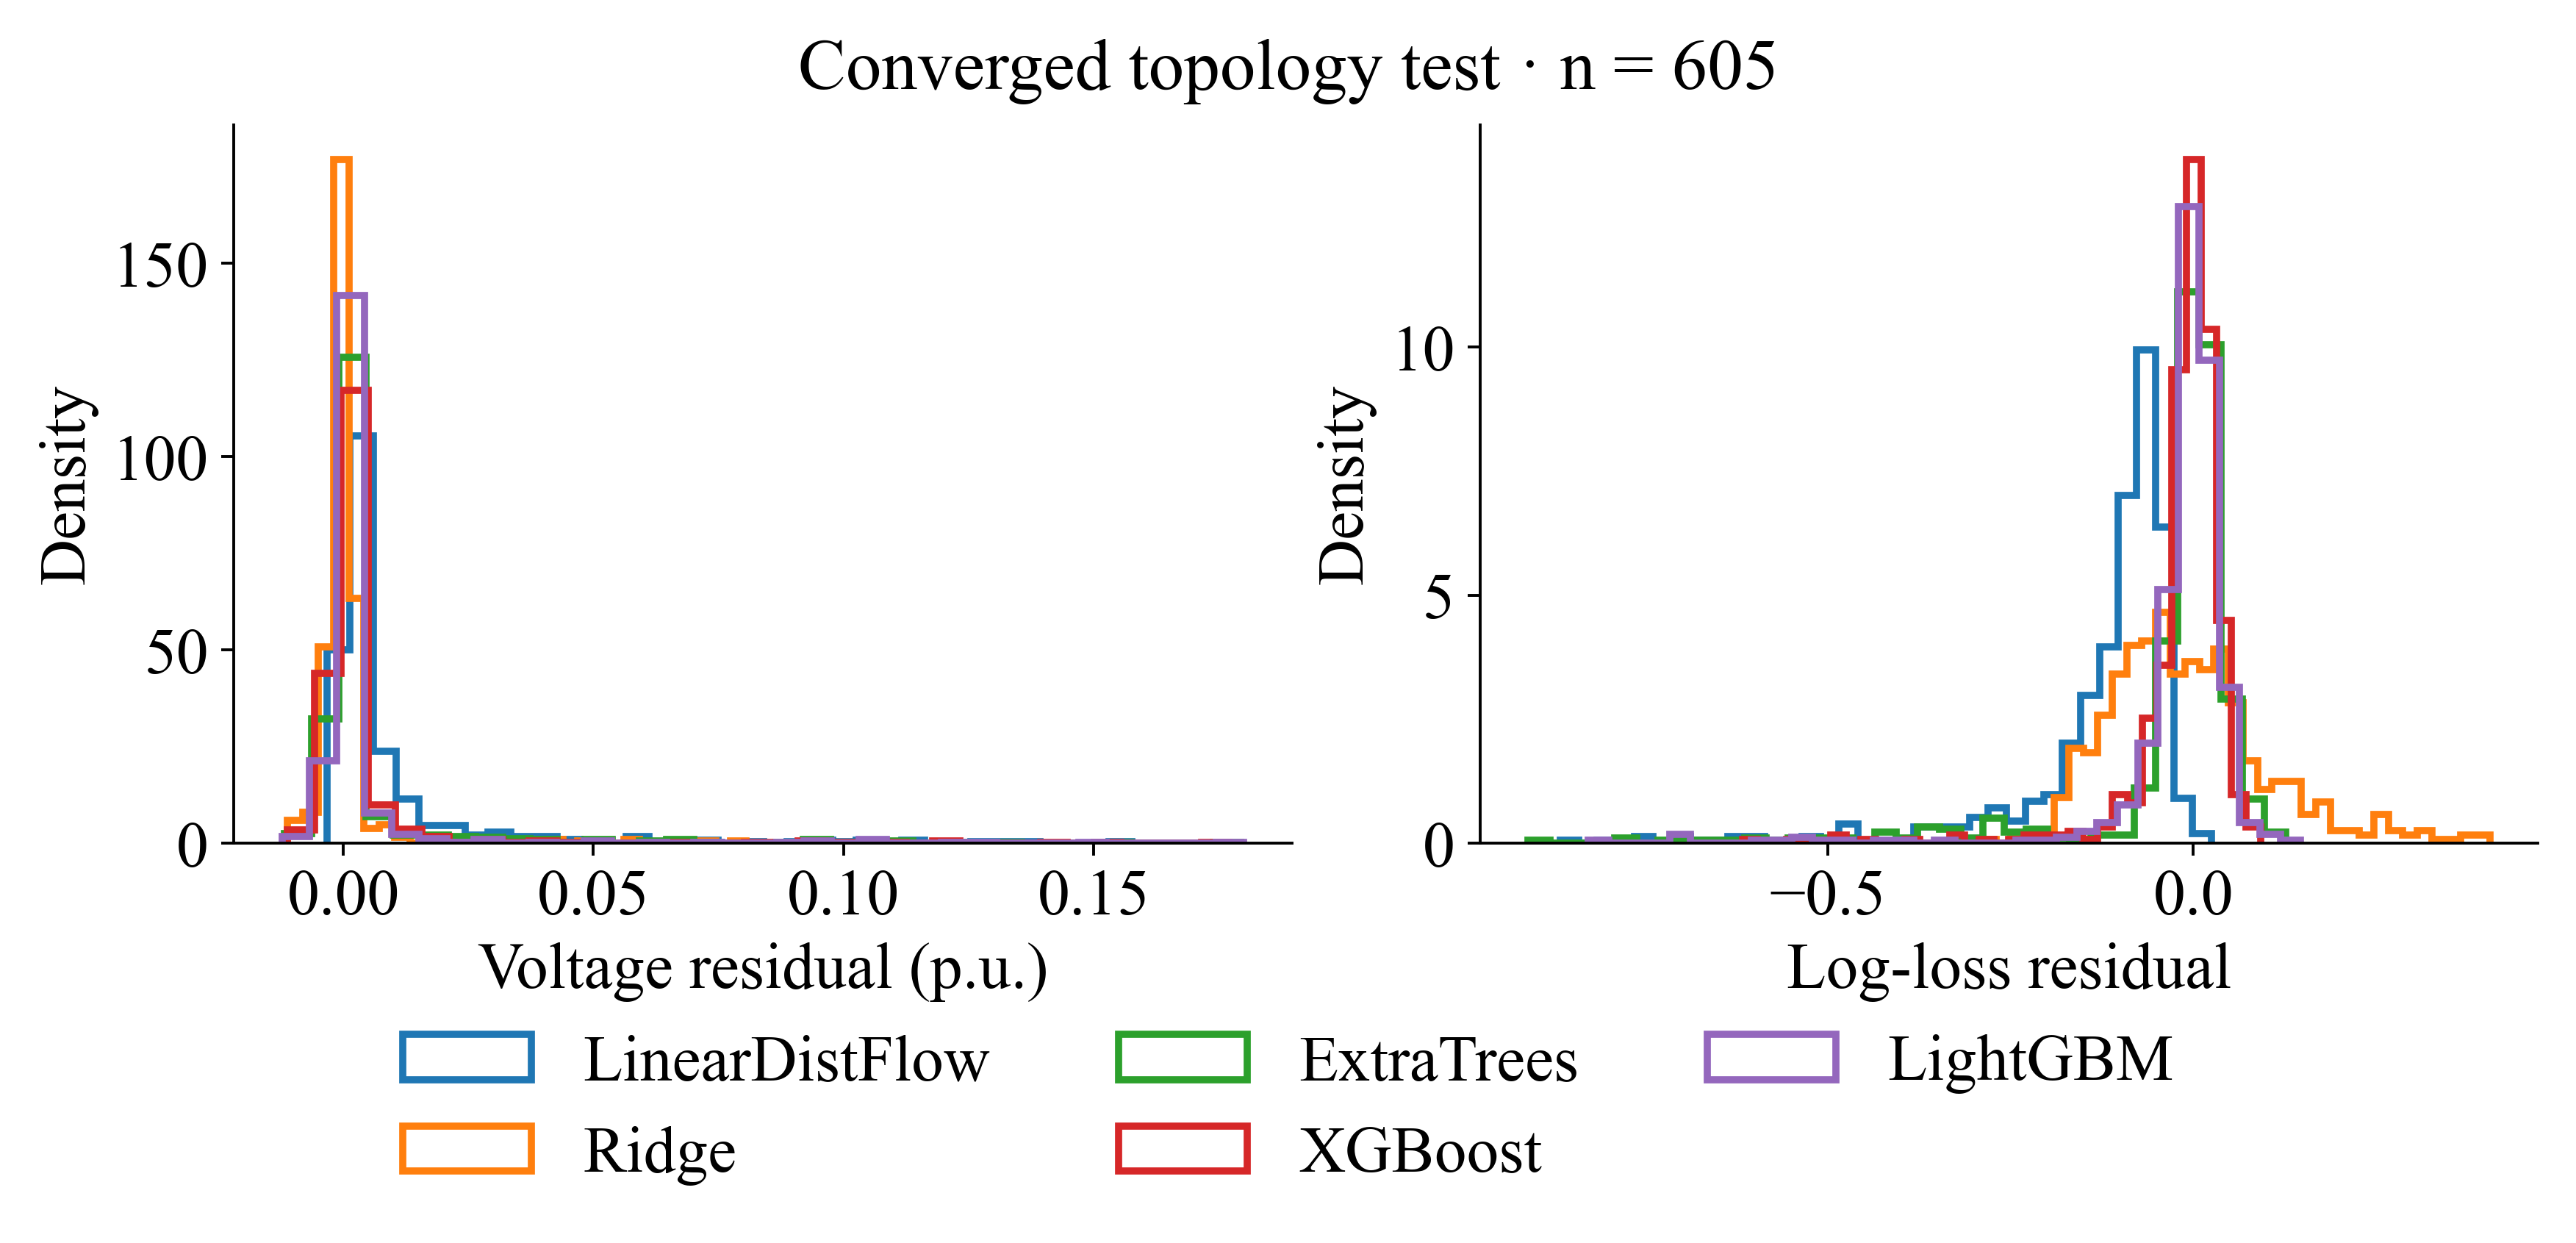

In [11]:
names = ["LinearDistFlow", "Ridge", "ExtraTrees", "XGBoost", "LightGBM"]
fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.7), layout="constrained")
residual_rows = []
for name in names:
    prediction, _ = load_predictions(name)
    voltage_error = prediction[valid_test, 0] - bundle.targets[valid_test, 0]
    log_error = np.log1p(prediction[valid_test, 1]) - np.log1p(bundle.targets[valid_test, 1])
    axes[0].hist(voltage_error, bins=35, density=True, histtype="step", linewidth=2, label=name)
    axes[1].hist(log_error, bins=35, density=True, histtype="step", linewidth=2, label=name)
    residual_rows.extend(
        dict(model=name, sample_id=int(row), voltage_residual=v, log_loss_residual=l)
        for row, v, l in zip(valid_test, voltage_error, log_error)
    )
axes[0].set(xlabel="Voltage residual (p.u.)", ylabel="Density")
axes[1].set(xlabel="Log-loss residual", ylabel="Density")
legend_handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(legend_handles, legend_labels, loc="outside lower center", ncol=3, frameon=False)
fig.suptitle(f"Converged topology test · n = {len(valid_test)}", fontsize=20)
save_figure(fig, FIGURES / "S1_Baseline_residuals.png")
plt.show()
pd.DataFrame(residual_rows).to_csv(TABLES / "03_residual_source.csv", index=False)

Residual shape exposes bias and heavy tails that average metrics hide. Different physical units are kept in separate panels; unresolved solver states do not contribute.

## Learning curve

Training size is varied while selection topologies remain fixed.

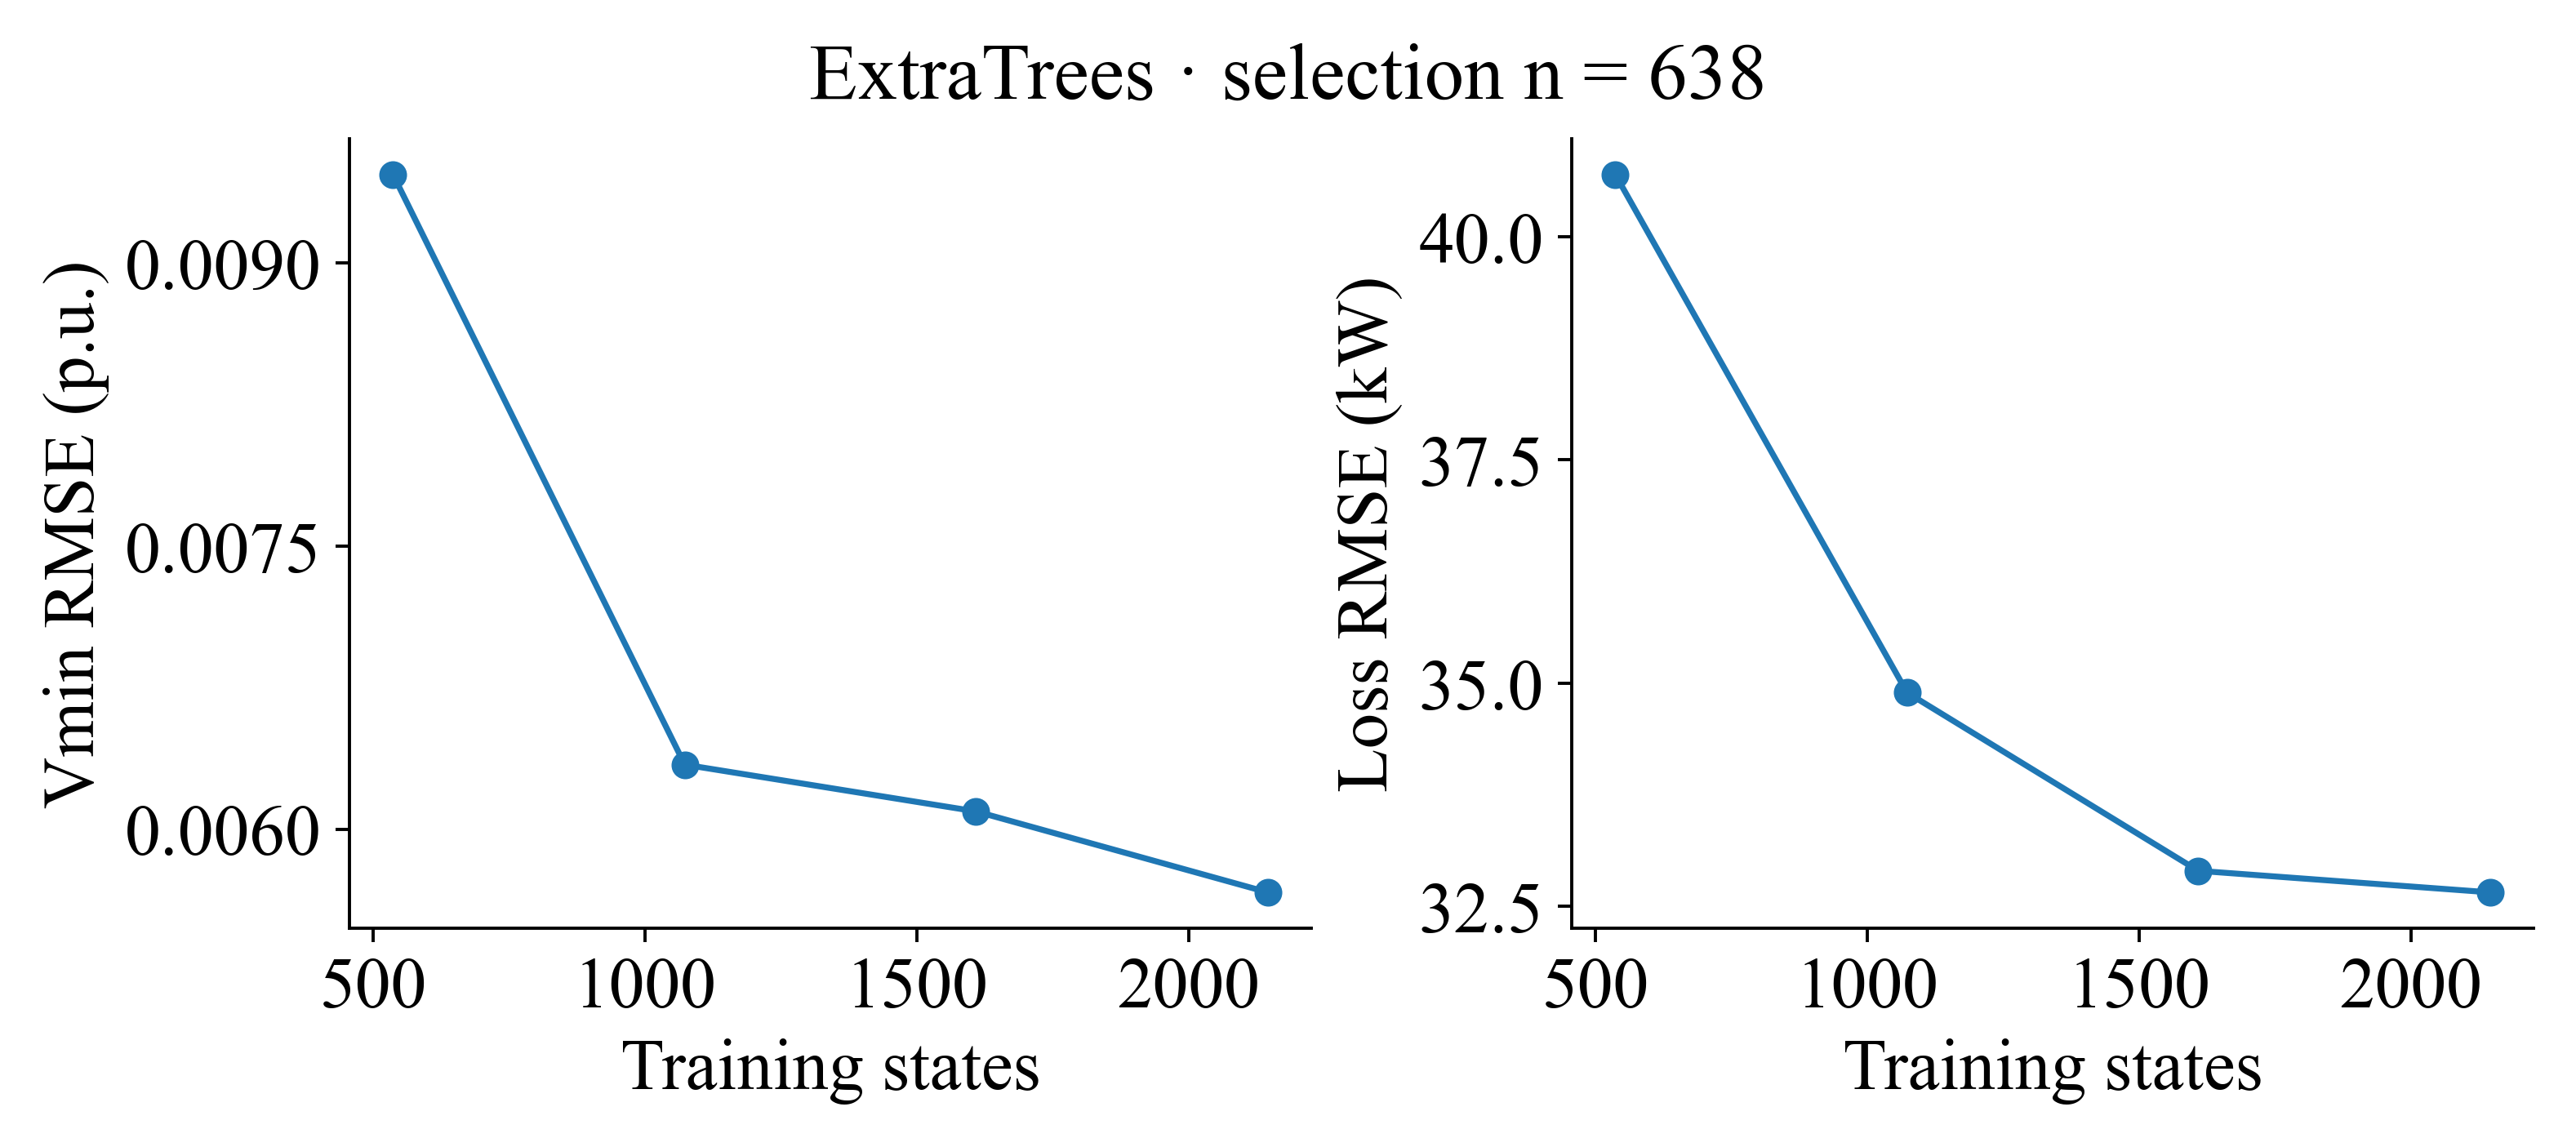

In [12]:
learning_rows = []
for fraction in [0.25, 0.5, 0.75, 1.0]:
    selected_training = rng.choice(
        training, max(100, int(len(training) * fraction)), replace=False
    )
    fitted = fit_tabular("ExtraTrees", bundle, selected_training)
    prediction, _ = predict_tabular(fitted, bundle, indices["selection"])
    learning_rows.append(
        dict(
            n=len(selected_training),
            **regression_metrics(bundle.targets[indices["selection"]], prediction)
        )
    )
learning = pd.DataFrame(learning_rows)
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.8), layout="constrained")
for axis, metric, label in zip(
    axes, ["vmin_rmse", "loss_rmse_kw"], ["Vmin RMSE (p.u.)", "Loss RMSE (kW)"]
):
    axis.plot(learning.n, learning[metric], marker="o")
    axis.set(xlabel="Training states", ylabel=label)
fig.suptitle("ExtraTrees · selection n = " + str(len(indices["selection"])), fontsize=20)
from matplotlib.ticker import MaxNLocator

for panel in axes:
    panel.xaxis.set_major_locator(MaxNLocator(nbins=4))
    panel.yaxis.set_major_locator(MaxNLocator(nbins=4))
save_figure(fig, FIGURES / "S2_Baseline_training_size_curve.png")
plt.show()
learning.to_csv(TABLES / "03_learning_source.csv", index=False)

The curve uses selection topologies. Within-training subsampling measures data-volume sensitivity while preserving the outer split; it does not estimate cross-feeder generalization.

## Comparator retention

Selection performance and model families identify reference methods for comparison.

In [13]:
retained = regression[regression.split.eq("selection converged")][
    ["model", "split", "n", "vmin_rmse", "loss_rmse_kw"]
].copy()
retained["selection_rank_vmin"] = retained.vmin_rmse.rank(method="min").astype(int)
roles = {
    "LinearDistFlow": "Physical approximation",
    "Ridge": "Linear correction",
    "RandomForest": "Bagged trees",
    "ExtraTrees": "Randomized trees",
    "MLP": "Tabular neural control",
    "XGBoost": "Gradient boosting",
    "LightGBM": "Leaf-wise boosting",
}
retained["role"] = retained.model.map(roles)
show_table(
    retained,
    ["model", "split", "n"],
    {
        "Selection evidence ↓": ["vmin_rmse", "loss_rmse_kw", "selection_rank_vmin"],
        "Scientific role": ["role"],
    },
    TABLES / "03_retention.csv",
    digits=6,
)

All baselines remain in the final comparison. Selection-set ranks identify strong reference methods; test performance is not used to remove competitors.